## Paper

**Author:** Jakob Balkovec<br>
**Date:** Sun Mar 22nd

This notebook includes the code for all of the plots that will be included in the paper.



In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
TRAIN = r'/Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data/splits/derived_8.0/train.csv'
TEST = r'/Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data/splits/derived_8.0/test.csv'
VAL =  r'/Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data/splits/derived_8.0/val.csv'

In [5]:
train_df = pd.read_csv(TRAIN)
val_df   = pd.read_csv(VAL)
test_df  = pd.read_csv(TEST)

for df in [train_df, val_df, test_df]:
    if "date" in df.columns:
        df["date"] = pd.to_datetime(df["date"], errors="coerce")

train_df["split"] = "train"
val_df["split"]   = "val"
test_df["split"]  = "test"

full_df = pd.concat([train_df, val_df, test_df], ignore_index=True)

print("train:", train_df.shape)
print("val  :", val_df.shape)
print("test :", test_df.shape)
print("full :", full_df.shape)
print("\nColumns preview:")
print(full_df.columns[:50].tolist())

train: (6868, 500)
val  : (2720, 500)
test : (4016, 500)
full : (13604, 500)

Columns preview:
['station_id', 'date', 'longitude', 'latitude', 'precip_mm', 's1_vv', 's1_vh', 's2_b4', 's2_b8', 's2_b11', 's2_b12', 'LST_modis', 'elev', 'slope', 'aspect', 'DOY', 'SMAP_sm_am_interp', 'SMAP_sm_pm_interp', 'soil_moisture_5cm', 'J_aspect_deg', 'J_bio_bio01', 'J_bio_bio02', 'J_bio_bio03', 'J_bio_bio04', 'J_bio_bio05', 'J_bio_bio06', 'J_bio_bio07', 'J_bio_bio08', 'J_bio_bio09', 'J_bio_bio10', 'J_bio_bio11', 'J_bio_bio12', 'J_bio_bio13', 'J_bio_bio14', 'J_bio_bio15', 'J_bio_bio16', 'J_bio_bio17', 'J_bio_bio18', 'J_bio_bio19', 'J_clay_plus_sand_b0', 'J_clay_wfrac_b0', 'J_clay_wfrac_b10', 'J_clay_wfrac_b100', 'J_clay_wfrac_b200', 'J_clay_wfrac_b30', 'J_clay_wfrac_b60', 'J_elev_m', 'J_lc_code', 'J_sand_clay_ratio_b0', 'J_sand_wfrac_b0']


In [7]:
TARGET_COL = "soil_moisture_5cm"
STATION_COL = "station_id"

stations = full_df[STATION_COL].dropna().unique().tolist()
print("Stations:", stations)

Stations: ['Darrington', 'SourdoughGulch_WA_985', 'Quinault', 'Touchet_WA_824', 'Spokane']


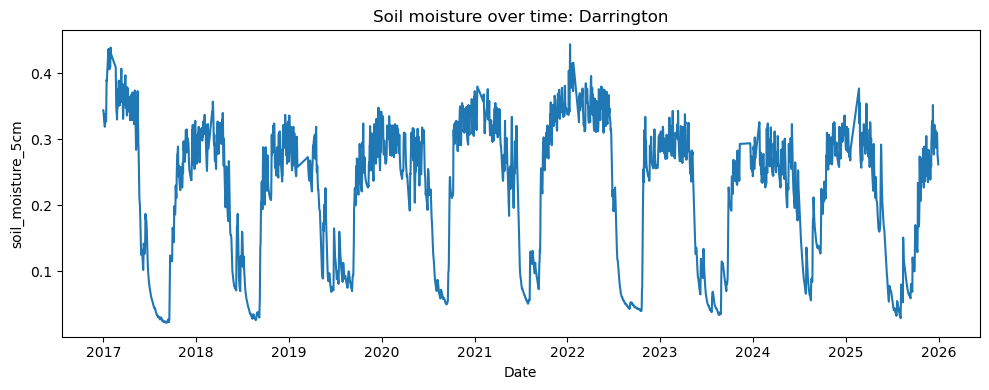

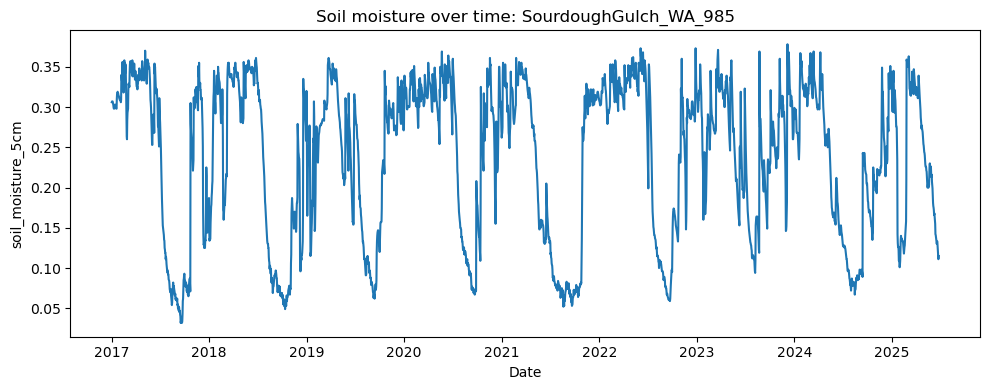

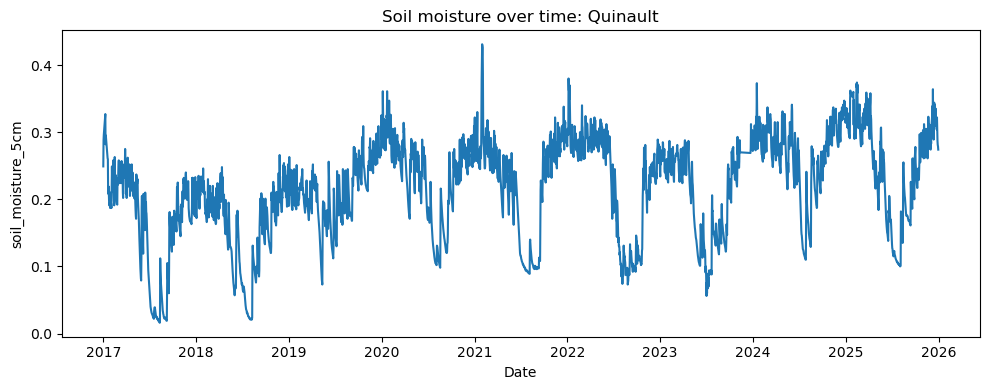

In [8]:
selected_stations = stations[:3]

for st in selected_stations:
    sub = full_df.loc[full_df[STATION_COL] == st].copy()
    sub = sub.sort_values("date")

    plt.figure(figsize=(10, 4))
    plt.plot(sub["date"], sub[TARGET_COL])
    plt.title(f"Soil moisture over time: {st}")
    plt.xlabel("Date")
    plt.ylabel(TARGET_COL)
    plt.tight_layout()
    plt.show()

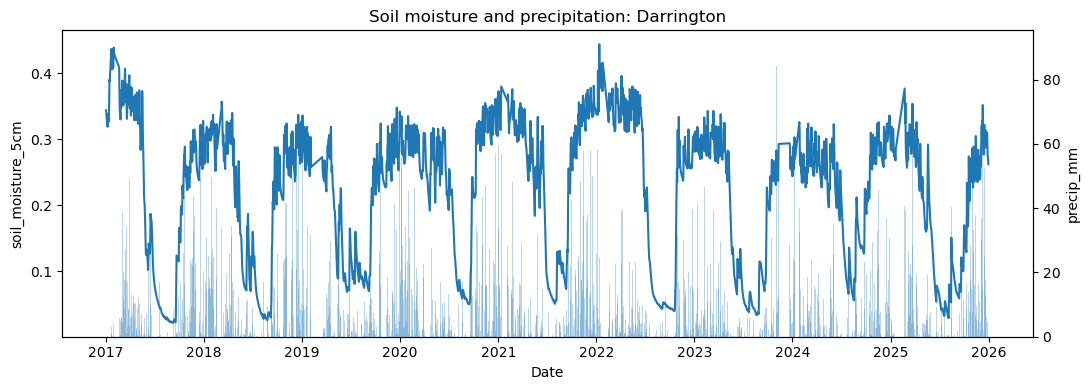

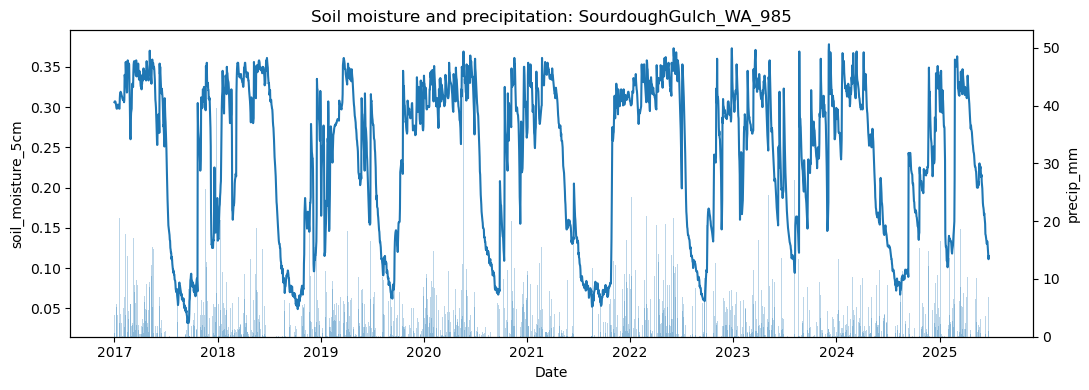

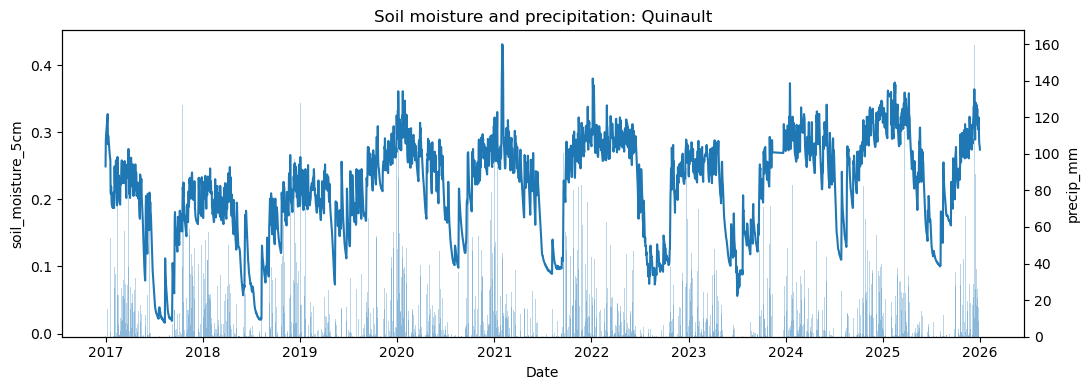

In [9]:
RAIN_COL = "precip_mm"   # change if needed
selected_stations = stations[:3]

for st in selected_stations:
    sub = full_df.loc[full_df[STATION_COL] == st].copy()
    sub = sub.sort_values("date")

    fig, ax1 = plt.subplots(figsize=(11, 4))

    ax1.plot(sub["date"], sub[TARGET_COL], label="Soil moisture")
    ax1.set_xlabel("Date")
    ax1.set_ylabel(TARGET_COL)

    ax2 = ax1.twinx()
    ax2.bar(sub["date"], sub[RAIN_COL], width=2, alpha=0.3)
    ax2.set_ylabel(RAIN_COL)

    plt.title(f"Soil moisture and precipitation: {st}")
    plt.tight_layout()
    plt.show()

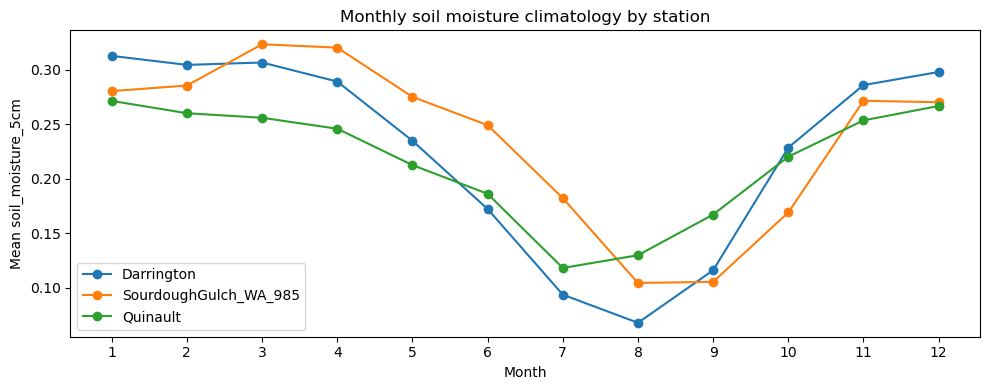

In [11]:
clim_df = full_df.dropna(subset=["date", TARGET_COL]).copy()
clim_df["month"] = clim_df["date"].dt.month

monthly = (
    clim_df.groupby([STATION_COL, "month"])[TARGET_COL]
    .mean()
    .reset_index()
)

selected_stations = stations[:3]

plt.figure(figsize=(10, 4))
for st in selected_stations:
    sub = monthly.loc[monthly[STATION_COL] == st]
    plt.plot(sub["month"], sub[TARGET_COL], marker="o", label=st)

plt.xticks(range(1, 13))
plt.xlabel("Month")
plt.ylabel(f"Mean {TARGET_COL}")
plt.title("Monthly soil moisture climatology by station")
plt.legend()
plt.tight_layout()
plt.show()

In [12]:
station_stats = (
    full_df.groupby(STATION_COL)[TARGET_COL]
    .agg(["count", "mean", "std", "min", "max"])
    .reset_index()
)

station_stats["range"] = station_stats["max"] - station_stats["min"]
station_stats = station_stats.sort_values("mean", ascending=False)

print(station_stats)

              station_id  count      mean       std    min    max  range
2  SourdoughGulch_WA_985   3096  0.239078  0.095761  0.032  0.378  0.346
0             Darrington   3047  0.219232  0.104517  0.022  0.444  0.422
1               Quinault   3204  0.214624  0.074648  0.016  0.431  0.415
3                Spokane   2690  0.168335  0.110735  0.011  0.359  0.348
4         Touchet_WA_824   1567  0.159020  0.087618  0.000  0.354  0.354


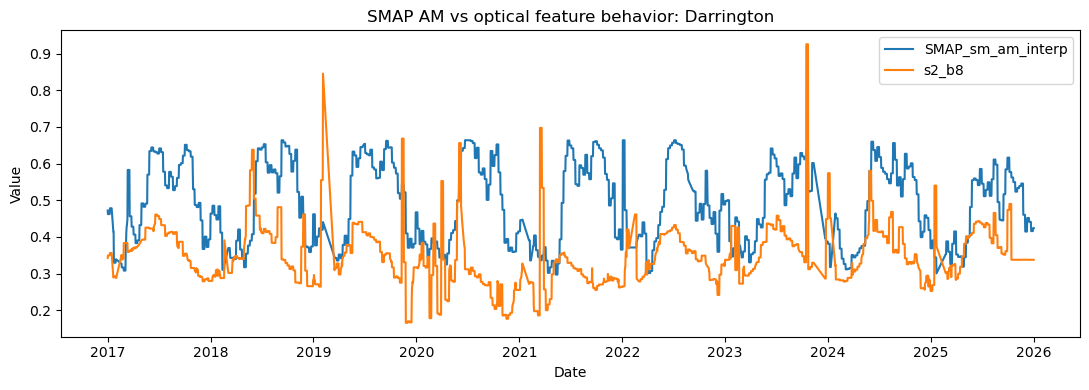

In [21]:
SMAP_COL = "SMAP_sm_am_interp"
OPTICAL_COL = "s2_b8"
selected_station = stations[0]

sub = full_df.loc[full_df[STATION_COL] == selected_station].copy()
sub = sub.sort_values("date")

plt.figure(figsize=(11, 4))
plt.plot(sub["date"], sub[SMAP_COL], label=SMAP_COL)
plt.plot(sub["date"], sub[OPTICAL_COL], label=OPTICAL_COL)
plt.xlabel("Date")
plt.ylabel("Value")
plt.title(f"SMAP AM vs optical feature behavior: {selected_station}")
plt.legend()
plt.tight_layout()
plt.show()

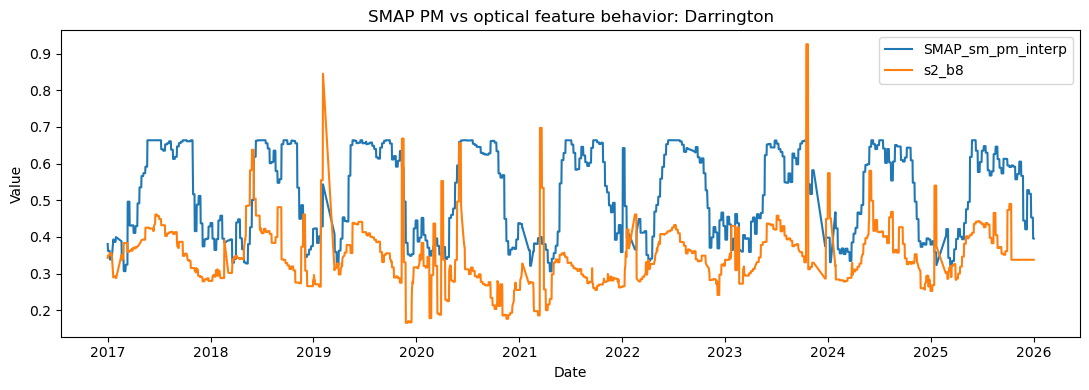

In [22]:
SMAP_COL = "SMAP_sm_pm_interp"
OPTICAL_COL = "s2_b8"
selected_station = stations[0]

sub = full_df.loc[full_df[STATION_COL] == selected_station].copy()
sub = sub.sort_values("date")

plt.figure(figsize=(11, 4))
plt.plot(sub["date"], sub[SMAP_COL], label=SMAP_COL)
plt.plot(sub["date"], sub[OPTICAL_COL], label=OPTICAL_COL)
plt.xlabel("Date")
plt.ylabel("Value")
plt.title(f"SMAP PM vs optical feature behavior: {selected_station}")
plt.legend()
plt.tight_layout()
plt.show()

    lag_days      corr
0          0  0.273890
1          1  0.183698
2          2  0.197838
3          3  0.205269
4          4  0.212400
5          5  0.211121
6          6  0.212268
7          7  0.211459
8          8  0.212109
9          9  0.210916
10        10  0.216086


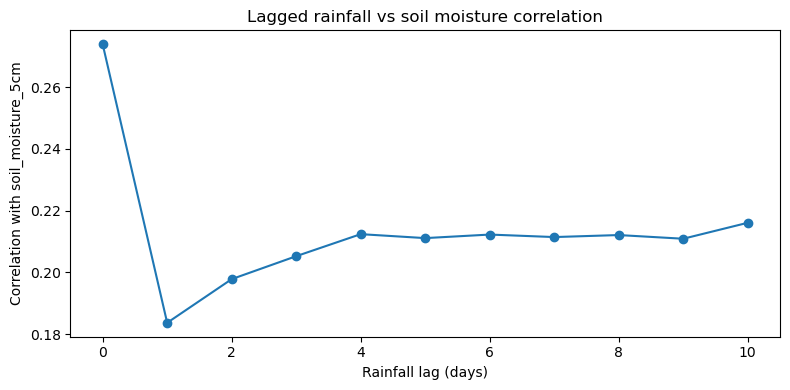

In [23]:
max_lag = 10
lag_corrs = []

tmp = full_df[[RAIN_COL, TARGET_COL]].dropna().copy()

for lag in range(max_lag + 1):
    shifted_rain = tmp[RAIN_COL].shift(lag)
    valid = pd.concat([shifted_rain, tmp[TARGET_COL]], axis=1).dropna()
    corr = valid.iloc[:, 0].corr(valid.iloc[:, 1])
    lag_corrs.append((lag, corr))

lag_corr_df = pd.DataFrame(lag_corrs, columns=["lag_days", "corr"])
print(lag_corr_df)

plt.figure(figsize=(8, 4))
plt.plot(lag_corr_df["lag_days"], lag_corr_df["corr"], marker="o")
plt.xlabel("Rainfall lag (days)")
plt.ylabel(f"Correlation with {TARGET_COL}")
plt.title("Lagged rainfall vs soil moisture correlation")
plt.tight_layout()
plt.show()